In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import make_column_transformer, make_column_selector
import os
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [2]:

glass = pd.read_csv(r"/home/sarthakredasani/Documents/CDAC_ML/Cases/Cases/Glass Identification/Glass.csv")
le = LabelEncoder()
glass['Type'] = le.fit_transform(glass['Type'])
X, y = glass.drop('Type', axis=1), glass['Type']



In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=25, test_size=0.3)



In [4]:
#### Hyper-Parameter Tuning

depths = [2,3,4,5,6, None]
min_samples = [2, 10, 20, 50, 75]
min_leaf = [1, 10, 20, 50, 75]
scores = []
for d in depths:
    for m in min_samples:
        for f in min_leaf:
                dtc = DecisionTreeClassifier(random_state=25, 
                        min_samples_leaf=f, max_depth=d, min_samples_split=m)
                dtc.fit(X_train, y_train)
                y_pred = dtc.predict(X_test)
                scores.append([d,m,f, accuracy_score(y_test, y_pred)])
df_scores = pd.DataFrame(scores, columns = ['Depth','Min Samples Split','Min Samples Leaf','score'])
df_scores.sort_values('score', ascending=False).iloc[0]


         

Depth                      NaN
Min Samples Split    10.000000
Min Samples Leaf      1.000000
score                 0.723077
Name: 130, dtype: float64

In [5]:
best_tree = DecisionTreeClassifier(random_state=25, 
                                   min_samples_leaf=1, max_depth=None, min_samples_split=10)
best_tree.fit(X,y)



DecisionTreeClassifier(min_samples_split=10, random_state=25)

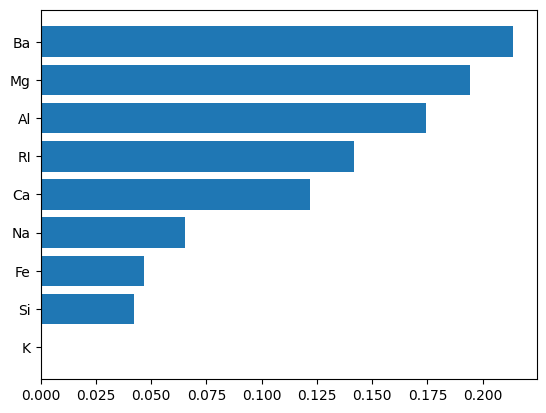

In [6]:
df_imp = pd.DataFrame({'Feature':list(X.columns),
                       'Importance':list(best_tree.feature_importances_)})
df_imp = df_imp.sort_values('Importance')
plt.barh(df_imp['Feature'], df_imp['Importance'])
plt.show()



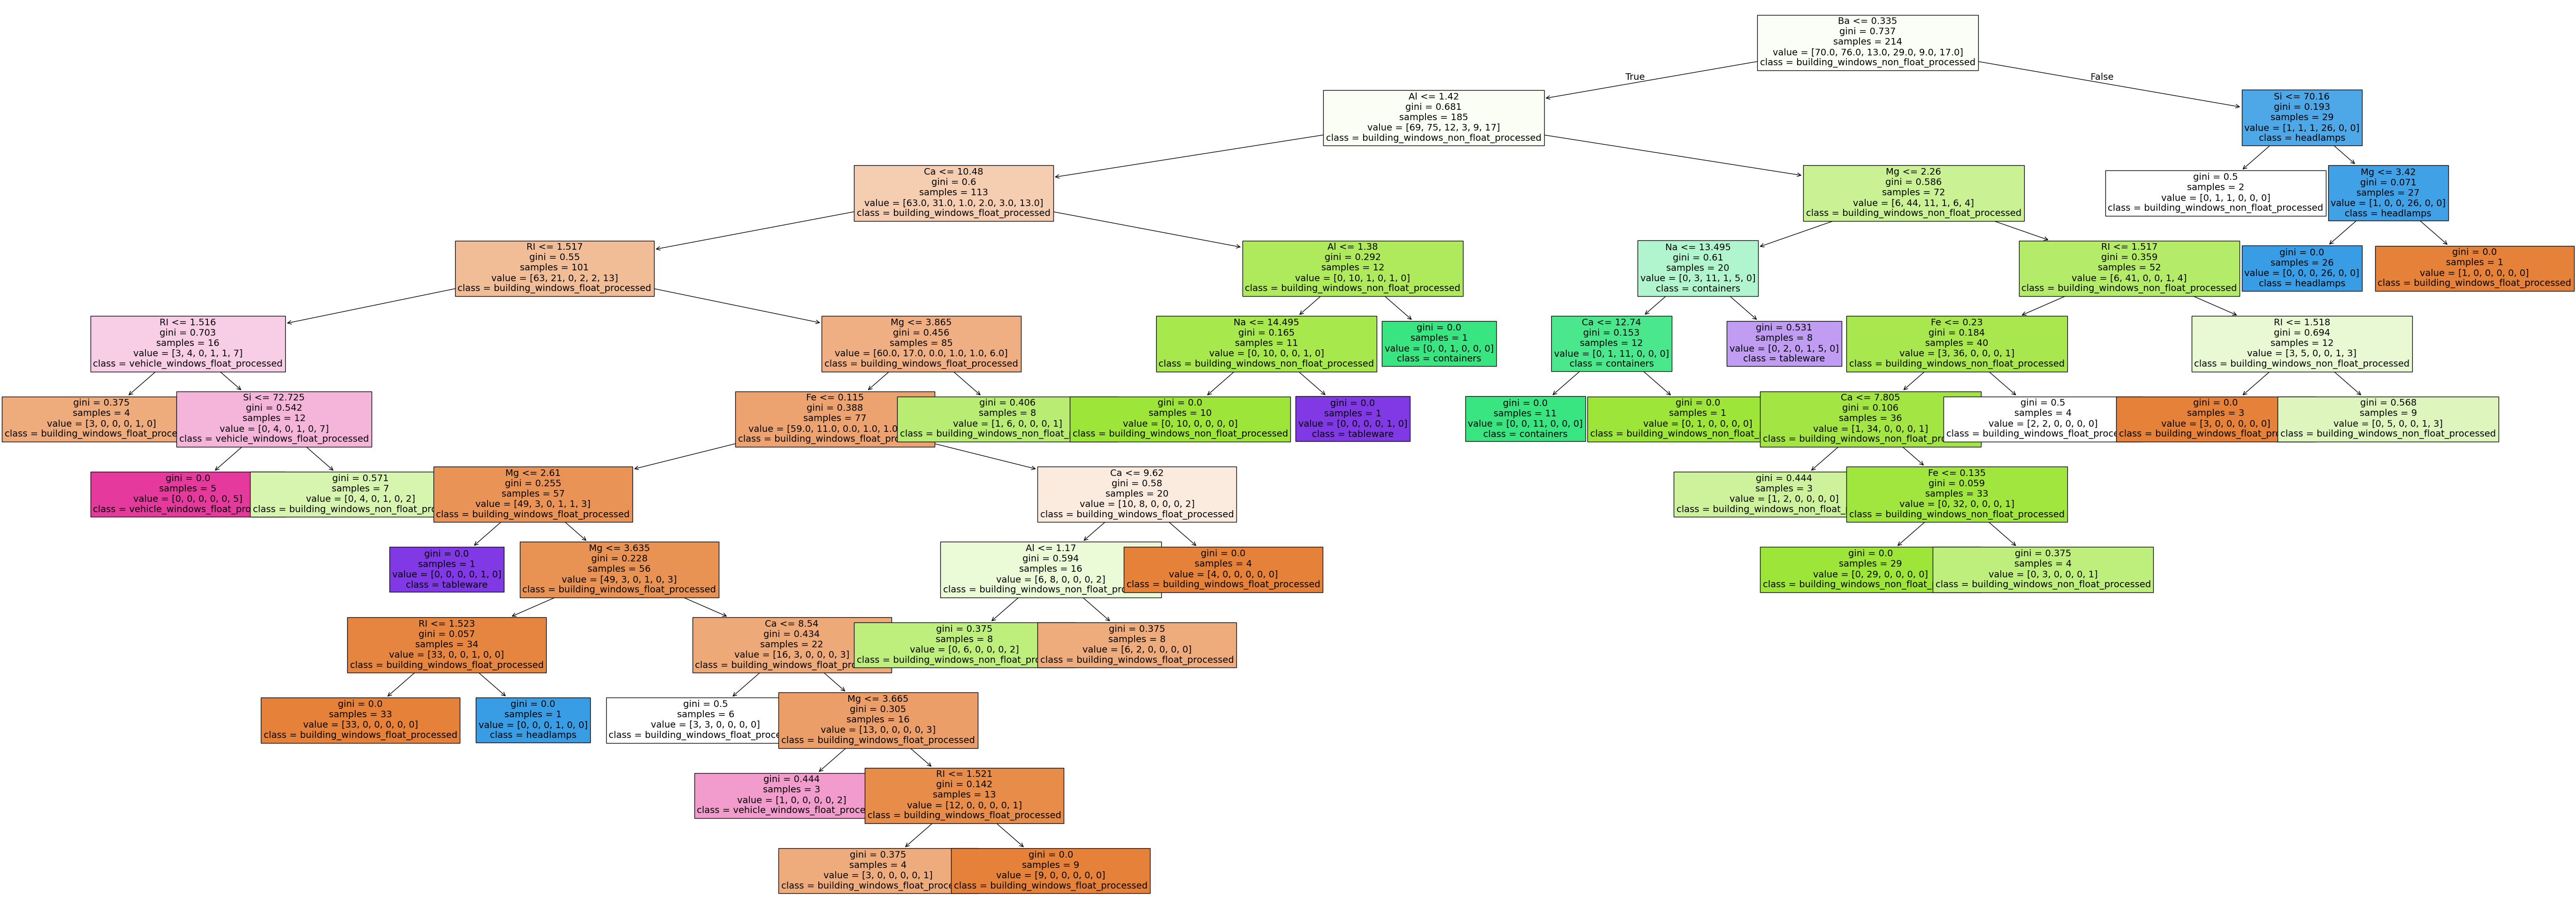

In [7]:
plt.figure(figsize=(70,25))
plot_tree(best_tree,feature_names=list(X.columns), 
          class_names=list(le.classes_), filled=True,fontsize=14)
plt.show() 
